# Smoke test 08: analytic joint spectro-photometry plumbing

This notebook was moved out of `notebooks/validation` because it uses an analytic stellar continuum and/or toy nebular lines. It is useful for fast plumbing checks, not real scientific validation.

# JADES-like joint NIRSpec + NIRCam fit at z=10

This notebook extends the previous JADES-like NIRSpec PRISM toy galaxy by adding broad-band photometry to the same likelihood.

The scientific point is narrow and auditable:

1. simulate one high-redshift spectrum on an approximate NIRSpec PRISM/CLEAR pixel grid;
2. simulate broad-band NIRCam-like photometry from the same SED;
3. treat blue non-detections as upper limits, not fake flux points;
4. run one joint NUTS fit with `GaussianSpectroPhotometricData`;
5. check that the posterior predictive spectrum and photometry both match the generator.

The filter curves below are simple trapezoids centered roughly on common NIRCam wide bands. They are **not official JWST throughput files**. For this validation notebook, that is intentional: the likelihood/data plumbing is the thing under test, not the observatory calibration.

In [1]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from sedinfer.experimental.jaxcigale import (
    GaussianPhotometricData,
    GaussianSpectralData,
    GaussianSpectroPhotometricData,
    JaxFilterSet,
    JaxParameterSpace,
    UniformJaxPrior,
    analytic_stellar_module,
    build_jax_sed_model,
    calzetti_attenuation_module,
    madau_igm_module,
    model_spectrum_on_observed_pixels,
    nebular_emulator_module,
    pixel_edges_from_centers_numpy,
    redshift_module,
    run_numpyro_nuts,
)
from sedinfer.experimental.jaxcigale.photometry import AB_FNU_CGS, C_A_PER_S

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})


def find_repo_root(start):
    path = Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "sedinfer").is_dir() and (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate sedinfer repository root.")


REPO_ROOT = find_repo_root(Path.cwd())
OUTPUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "jades_like_joint_spectrophotometry"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIT_FILE = OUTPUT_DIR / "nuts_jades_like_joint_fit.npz"
SUMMARY_FILE = OUTPUT_DIR / "nuts_jades_like_joint_fit_summary.json"

RUN_NUTS = not FIT_FILE.exists()
print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())
print("Output directory:", OUTPUT_DIR)
print("Run NUTS in this execution:", RUN_NUTS)

JAX backend: cpu
JAX devices: [CpuDevice(id=0)]
Output directory: /Users/gregoire/Documents/Sedfitting/sedinfer-public/notebooks/outputs/jades_like_joint_spectrophotometry
Run NUTS in this execution: True


## NIRSpec PRISM/CLEAR pixels

The spectrum is compared after two operations that mimic the instrument response:

- a wavelength-dependent Gaussian line-spread function with `R(lambda)`;
- flux-conserving integration over spectral pixel edges.

Wavelengths are observed-frame Angstrom internally. Plot labels use microns.

PRISM-like pixels: 712
Observed wavelength range: 0.60-5.30 micron
Resolving-power range: 30.0-330.0


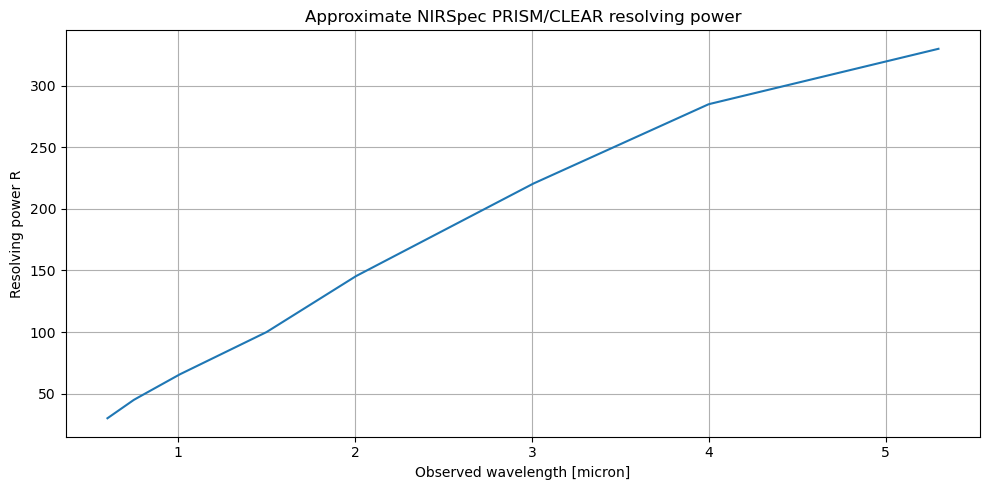

In [2]:
def approximate_nirspec_prism_resolving_power(wave_um):
    """Smooth approximation to NIRSpec PRISM/CLEAR R(lambda).

    Public instrument summaries put PRISM/CLEAR around R~30 at the blue end and
    R~300 at the red end. This simple monotonic curve is enough for a mock
    likelihood validation.
    """

    wave_um = np.asarray(wave_um, dtype=float)
    anchor_wave = np.array([0.60, 0.75, 1.00, 1.50, 2.00, 3.00, 4.00, 5.30])
    anchor_r = np.array([30.0, 45.0, 65.0, 100.0, 145.0, 220.0, 285.0, 330.0])
    return np.interp(wave_um, anchor_wave, anchor_r)


def make_prism_pixel_grid(wave_min_um=0.60, wave_max_um=5.30, pixels_per_resolution_element=2.2):
    centers = [float(wave_min_um)]
    while centers[-1] < wave_max_um:
        r_here = float(approximate_nirspec_prism_resolving_power(centers[-1]))
        delta_um = centers[-1] / (pixels_per_resolution_element * r_here)
        centers.append(centers[-1] + delta_um)
    centers = np.asarray(centers)
    centers = centers[centers <= wave_max_um]
    return centers * 1.0e4  # micron -> Angstrom


spectral_wave_a = make_prism_pixel_grid()
spectral_edges_a = pixel_edges_from_centers_numpy(spectral_wave_a)
resolving_power = approximate_nirspec_prism_resolving_power(spectral_wave_a / 1.0e4)

print(f"PRISM-like pixels: {spectral_wave_a.size}")
print(f"Observed wavelength range: {spectral_wave_a[0]/1e4:.2f}-{spectral_wave_a[-1]/1e4:.2f} micron")
print(f"Resolving-power range: {resolving_power.min():.1f}-{resolving_power.max():.1f}")

fig, ax = plt.subplots()
ax.plot(spectral_wave_a / 1.0e4, resolving_power)
ax.set_xlabel("Observed wavelength [micron]")
ax.set_ylabel("Resolving power R")
ax.set_title("Approximate NIRSpec PRISM/CLEAR resolving power")
fig.tight_layout()

## Broad-band filters

The filter curves are trapezoids. For a real JADES analysis, replace this cell with official NIRCam throughput curves and keep the rest of the notebook unchanged.

,name,center_um,width_um,five_sigma_depth_ab
0,F090W,0.90,0.25,29.4
1,F115W,1.15,0.30,29.6
2,F150W,1.50,0.40,29.7
3,F200W,2.00,0.55,29.7
4,F277W,2.77,0.75,29.5
5,F356W,3.56,0.85,29.3
6,F444W,4.44,1.00,29.1


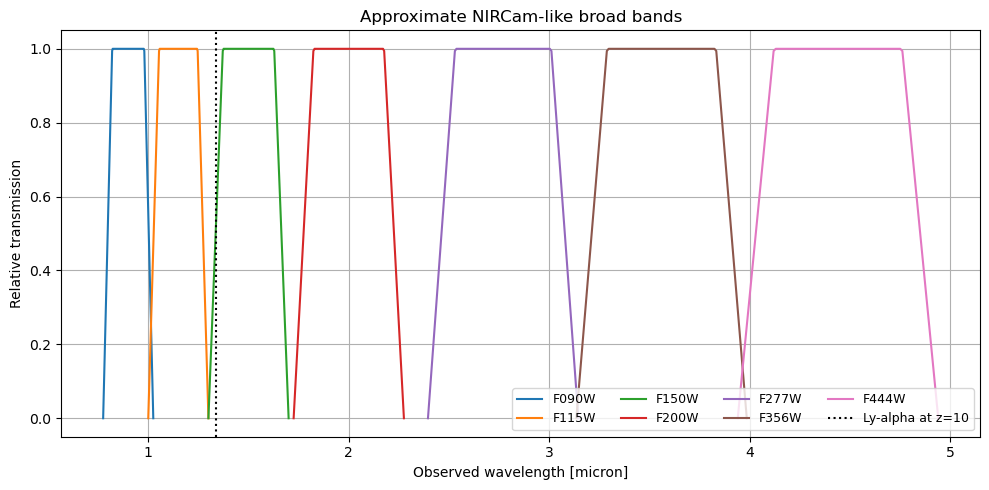

In [3]:
def trapezoid_filter(center_um, width_um, edge_fraction=0.18, n=96):
    """Return a simple normalized trapezoid filter curve in Angstrom."""

    half = 0.5 * width_um
    edge = edge_fraction * width_um
    wave_um = np.linspace(center_um - half, center_um + half, n)
    left = center_um - half + edge
    right = center_um + half - edge
    transmission = np.ones_like(wave_um)
    transmission = np.where(wave_um < left, (wave_um - (center_um - half)) / edge, transmission)
    transmission = np.where(wave_um > right, ((center_um + half) - wave_um) / edge, transmission)
    transmission = np.clip(transmission, 0.0, 1.0)
    return wave_um * 1.0e4, transmission


filter_table = pd.DataFrame(
    {
        "name": ["F090W", "F115W", "F150W", "F200W", "F277W", "F356W", "F444W"],
        "center_um": [0.90, 1.15, 1.50, 2.00, 2.77, 3.56, 4.44],
        "width_um": [0.25, 0.30, 0.40, 0.55, 0.75, 0.85, 1.00],
        "five_sigma_depth_ab": [29.4, 29.6, 29.7, 29.7, 29.5, 29.3, 29.1],
    }
)

filter_waves = []
filter_trans = []
for row in filter_table.itertuples(index=False):
    wave, trans = trapezoid_filter(row.center_um, row.width_um)
    filter_waves.append(wave)
    filter_trans.append(trans)

filters = JaxFilterSet.from_curves(filter_table["name"], filter_waves, filter_trans)
filter_effective_wave_a = np.array([
    np.trapezoid(w * t, w) / np.trapezoid(t, w)
    for w, t in zip(filter_waves, filter_trans)
])

fig, ax = plt.subplots()
for name, wave, trans in zip(filters.names, filter_waves, filter_trans):
    ax.plot(wave / 1.0e4, trans, label=name)
ax.axvline(1215.67 * (1.0 + 10.0) / 1.0e4, color="black", ls=":", label="Ly-alpha at z=10")
ax.set_xlabel("Observed wavelength [micron]")
ax.set_ylabel("Relative transmission")
ax.set_title("Approximate NIRCam-like broad bands")
ax.legend(ncol=4, fontsize=9)
fig.tight_layout()

filter_table

## SED model

This validation source deliberately uses a simple analytic stellar continuum plus toy nebular lines. The fitted parameters are:

- `log10_mass`: stellar mass normalization applied exactly once by `JaxSedModel`;
- `z`: redshift;
- `logzsol`: metallicity-like continuum parameter;
- `dust2`: attenuation amplitude in magnitudes;
- `line_scale`: toy nebular-line amplitude.

The model returns observed `f_lambda` for spectra and maggies for photometry.

In [4]:
def toy_highz_nebular_lines(wave_rest_a, line_scale=1.0, logzsol=-0.5):
    """Toy rest-frame nebular spectrum in Lsun/Angstrom per solar mass."""

    wave = jnp.asarray(wave_rest_a)
    metallicity_factor = 10.0 ** (0.15 * logzsol)
    scale = line_scale * metallicity_factor

    continuum = 3.0e-9 * scale * (wave / 3000.0) ** -0.3

    def gaussian(center_a, sigma_a, equivalent_width_a):
        local_continuum = 2.0e-7 * (center_a / 5500.0) ** -1.4
        amplitude = local_continuum * equivalent_width_a / (jnp.sqrt(2.0 * jnp.pi) * sigma_a)
        return amplitude * jnp.exp(-0.5 * ((wave - center_a) / sigma_a) ** 2)

    lines = scale * (
        gaussian(1215.67, 1.2, 80.0)
        + gaussian(1908.7, 1.5, 25.0)
        + gaussian(3727.0, 2.0, 70.0)
        + gaussian(4102.0, 2.0, 18.0)
        + gaussian(4341.0, 2.0, 25.0)
        + gaussian(4861.0, 2.5, 35.0)
        + gaussian(5007.0, 2.5, 120.0)
    )
    return continuum, lines


wave_rest_a = np.linspace(500.0, 5600.0, 900)
parameter_names = ["log10_mass", "z", "logzsol", "dust2", "line_scale"]
parameter_space = JaxParameterSpace(
    names=parameter_names,
    priors={
        "log10_mass": UniformJaxPrior(8.0, 10.6),
        "z": UniformJaxPrior(8.5, 11.5),
        "logzsol": UniformJaxPrior(-1.5, 0.2),
        "dust2": UniformJaxPrior(0.0, 0.5),
        "line_scale": UniformJaxPrior(0.1, 3.0),
    },
)

model = build_jax_sed_model(
    modules=[
        analytic_stellar_module(),
        nebular_emulator_module(toy_highz_nebular_lines, parameter_names=("line_scale", "logzsol")),
        calzetti_attenuation_module(av_parameter="dust2", slope_parameter=None, bump_amplitude_parameter=None),
        madau_igm_module(),
        redshift_module(),
    ],
    wavelength_grid_a=wave_rest_a,
    filters=filters,
    parameter_space=parameter_space,
)

true_theta = np.array([9.15, 10.0, -0.65, 0.08, 1.25])
initial_theta = np.array([9.0, 9.8, -0.5, 0.05, 1.0])

pd.DataFrame({"parameter": parameter_names, "truth": true_theta, "initial": initial_theta})

,parameter,truth,initial
0,log10_mass,9.15,9.00
1,z,10.00,9.80
2,logzsol,-0.65,-0.50
3,dust2,0.08,0.05
4,line_scale,1.25,1.00


## Simulate spectrum and photometry

Masks/cuts are explicit:

- the spectrum masks the blue edge and two generic problematic windows;
- photometry uses all bands;
- `F090W` and `F115W` are encoded as upper limits because the Lyman break lies inside/beyond them at `z=10`.

In [5]:
def maggies_to_abmag(maggies):
    maggies = np.asarray(maggies, dtype=float)
    return -2.5 * np.log10(np.maximum(maggies, 1.0e-300))


def abmag_to_maggies(mag_ab):
    return 10.0 ** (-0.4 * np.asarray(mag_ab, dtype=float))


def maggies_to_flam_at_wave(maggies, wave_a):
    fnu_cgs = np.asarray(maggies, dtype=float) * AB_FNU_CGS
    return fnu_cgs * C_A_PER_S / np.asarray(wave_a, dtype=float) ** 2


rng = np.random.default_rng(2026)
state_true = model.run_modules_mass_scaled(jnp.asarray(true_theta))
true_flux_pixel = np.asarray(
    model_spectrum_on_observed_pixels(
        state_true.wave_obs_a,
        state_true.flux_lambda_cgs,
        jnp.asarray(spectral_wave_a),
        jnp.asarray(spectral_edges_a),
        resample_mode="bin",
        resolving_power=resolving_power,
    )
)
true_phot_maggies = np.asarray(model.predict_photometry(jnp.asarray(true_theta)))

# Spectrum noise: finite floor plus 10% fractional component.
red_continuum = np.nanmedian(true_flux_pixel[(spectral_wave_a > 16000.0) & (spectral_wave_a < 35000.0)])
noise_floor = 0.05 * red_continuum
sigma_flux = 0.10 * np.abs(true_flux_pixel) + noise_floor
observed_flux = true_flux_pixel + rng.normal(0.0, sigma_flux)

spectral_mask = np.ones_like(spectral_wave_a, dtype=bool)
for lo_um, hi_um in [(0.60, 0.68), (2.85, 2.95), (4.95, 5.05)]:
    spectral_mask &= ~((spectral_wave_a / 1e4 >= lo_um) & (spectral_wave_a / 1e4 <= hi_um))

# Photometric noise: detections get fractional errors plus depth floor.
five_sigma_depth_maggies = abmag_to_maggies(filter_table["five_sigma_depth_ab"].to_numpy())
phot_sigma_maggies = np.maximum(0.08 * np.abs(true_phot_maggies), five_sigma_depth_maggies / 5.0)
phot_observed_maggies = true_phot_maggies + rng.normal(0.0, phot_sigma_maggies)

upper_limit_mask = np.array([name in {"F090W", "F115W"} for name in filters.names])
phot_flux_for_likelihood = phot_observed_maggies.copy()
phot_flux_for_likelihood[upper_limit_mask] = np.nan

phot_data = GaussianPhotometricData(
    flux_maggies=phot_flux_for_likelihood,
    sigma_maggies=phot_sigma_maggies,
    mask=np.ones(len(filters.names), dtype=bool),
    upper_limit_maggies=five_sigma_depth_maggies,
    upper_limit_mask=upper_limit_mask,
)
spectral_data = GaussianSpectralData(
    wavelength_obs_a=spectral_wave_a,
    flux_lambda_cgs=observed_flux,
    sigma_lambda_cgs=sigma_flux,
    mask=spectral_mask,
    pixel_edges_obs_a=spectral_edges_a,
    resolving_power=resolving_power,
    resample_mode="bin",
)
joint_data = GaussianSpectroPhotometricData(photometry=phot_data, spectrum=spectral_data)

lya_obs_um = 1215.67 * (1.0 + true_theta[1]) / 1.0e4
print(f"Ly-alpha observed wavelength: {lya_obs_um:.3f} micron")
print(f"Active spectral pixels: {spectral_mask.sum()} / {spectral_mask.size}")
print("Photometric bands:", list(filters.names))
print("Upper-limit bands:", list(np.asarray(filters.names)[upper_limit_mask]))

phot_summary = pd.DataFrame(
    {
        "band": filters.names,
        "lambda_eff_um": filter_effective_wave_a / 1.0e4,
        "truth_AB": maggies_to_abmag(true_phot_maggies),
        "observed_AB": maggies_to_abmag(np.abs(phot_observed_maggies)),
        "sigma_maggies": phot_sigma_maggies,
        "five_sigma_depth_AB": filter_table["five_sigma_depth_ab"],
        "is_upper_limit": upper_limit_mask,
    }
)
phot_summary

Ly-alpha observed wavelength: 1.337 micron
Active spectral pixels: 672 / 712
Photometric bands: ['F090W', 'F115W', 'F150W', 'F200W', 'F277W', 'F356W', 'F444W']
Upper-limit bands: [np.str_('F090W'), np.str_('F115W')]


,band,lambda_eff_um,truth_AB,observed_AB,sigma_maggies,five_sigma_depth_AB,is_upper_limit
0,F090W,0.90,52.831982,32.238905,3.475602e-13,29.4,True
1,F115W,1.15,50.297499,31.630314,2.890880e-13,29.6,True
2,F150W,1.50,38.096367,31.631895,2.636513e-13,29.7,False
3,F200W,2.00,37.719455,33.201102,2.636513e-13,29.7,False
4,F277W,2.77,37.492276,30.824284,3.169786e-13,29.5,False
5,F356W,3.56,37.270705,31.394875,3.810921e-13,29.3,False
6,F444W,4.44,36.941220,31.661838,4.581735e-13,29.1,False


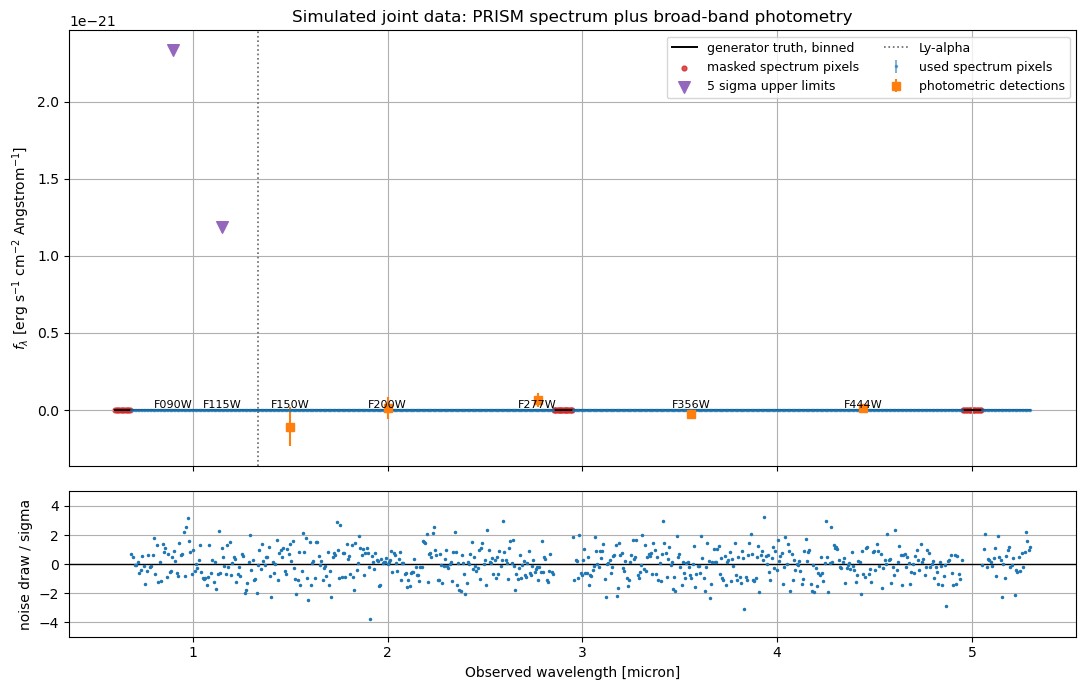

In [6]:
fig, (ax, rx) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
wave_um = spectral_wave_a / 1.0e4
ax.plot(wave_um, true_flux_pixel, color="black", lw=1.4, label="generator truth, binned")
ax.errorbar(wave_um[spectral_mask], observed_flux[spectral_mask], yerr=sigma_flux[spectral_mask], fmt=".", ms=3, alpha=0.55, label="used spectrum pixels")
ax.scatter(wave_um[~spectral_mask], observed_flux[~spectral_mask], s=12, color="tab:red", alpha=0.8, label="masked spectrum pixels")

phot_flam = maggies_to_flam_at_wave(phot_observed_maggies, filter_effective_wave_a)
phot_sigma_flam = maggies_to_flam_at_wave(phot_sigma_maggies, filter_effective_wave_a)
upper_flam = maggies_to_flam_at_wave(five_sigma_depth_maggies, filter_effective_wave_a)

is_det = ~upper_limit_mask
ax.errorbar(filter_effective_wave_a[is_det] / 1.0e4, phot_flam[is_det], yerr=phot_sigma_flam[is_det], fmt="s", ms=6, color="tab:orange", label="photometric detections")
ax.scatter(filter_effective_wave_a[upper_limit_mask] / 1.0e4, upper_flam[upper_limit_mask], marker="v", s=70, color="tab:purple", label="5 sigma upper limits")
for wave, trans, name in zip(filter_waves, filter_trans, filters.names):
    scale = 0.22 * np.nanmax(true_flux_pixel)
    ax.fill_between(wave / 1.0e4, 0.0, trans * scale, alpha=0.10)
    ax.text(np.mean(wave) / 1.0e4, scale * 1.05, name, ha="center", va="bottom", fontsize=8)

ax.axvline(lya_obs_um, color="0.4", ls=":", lw=1.2, label="Ly-alpha")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
ax.set_title("Simulated joint data: PRISM spectrum plus broad-band photometry")
ax.legend(loc="upper right", ncol=2, fontsize=9)

rx.axhline(0.0, color="black", lw=1)
rx.plot(wave_um[spectral_mask], ((observed_flux - true_flux_pixel) / sigma_flux)[spectral_mask], ".", ms=3)
rx.set_xlabel("Observed wavelength [micron]")
rx.set_ylabel("noise draw / sigma")
rx.set_ylim(-5, 5)
fig.tight_layout()

## Joint NUTS fit

The log posterior is:

`log prior + spectral Gaussian likelihood + photometric Gaussian detections + photometric upper-limit CDF terms`.

The sampler returns samples in physical parameter coordinates, not transformed NUTS coordinates.

In [7]:
if RUN_NUTS:
    t0 = time.perf_counter()
    nuts_result = run_numpyro_nuts(
        model=model,
        data=joint_data,
        initial_theta=jnp.asarray(initial_theta),
        num_warmup=100,
        num_samples=160,
        rng_seed=18,
        progress_bar=True,
        target_accept_prob=0.82,
        max_tree_depth=7,
        dense_mass=True,
    )
    runtime = time.perf_counter() - t0
    np.savez(
        FIT_FILE,
        samples=nuts_result.samples,
        log_prob=nuts_result.log_prob,
        theta_names=np.asarray(nuts_result.theta_names),
        truth=true_theta,
        initial=initial_theta,
        spectral_wave_a=spectral_wave_a,
        spectral_edges_a=spectral_edges_a,
        resolving_power=resolving_power,
        observed_flux=observed_flux,
        sigma_flux=sigma_flux,
        spectral_mask=spectral_mask,
        true_flux_pixel=true_flux_pixel,
        true_phot_maggies=true_phot_maggies,
        phot_observed_maggies=phot_observed_maggies,
        phot_sigma_maggies=phot_sigma_maggies,
        upper_limit_maggies=five_sigma_depth_maggies,
        upper_limit_mask=upper_limit_mask,
        filter_effective_wave_a=filter_effective_wave_a,
        runtime_seconds=np.asarray(runtime),
    )
    extra = nuts_result.extra_fields.get("numpyro", {})
    summary = {
        "runtime_seconds": float(runtime),
        "n_samples": int(nuts_result.samples.shape[0]),
        "jax_backend": jax.default_backend(),
        "accept_prob_mean": float(np.mean(np.asarray(extra.get("accept_prob", np.nan)))),
        "n_divergences": int(np.sum(np.asarray(extra.get("diverging", [])))) if "diverging" in extra else None,
        "n_spectral_pixels": int(spectral_mask.size),
        "n_active_spectral_pixels": int(spectral_mask.sum()),
        "n_photometric_bands": int(len(filters.names)),
        "n_upper_limits": int(upper_limit_mask.sum()),
    }
    SUMMARY_FILE.write_text(json.dumps(summary, indent=2))
else:
    print("Loading existing fit", FIT_FILE)

fit = np.load(FIT_FILE, allow_pickle=True)
samples = fit["samples"]
log_prob = fit["log_prob"]
theta_names = [str(x) for x in fit["theta_names"]]
truth = fit["truth"]
runtime = float(fit["runtime_seconds"])
print(f"Loaded samples: {samples.shape}")
print(f"Runtime: {runtime:.2f} s")
if SUMMARY_FILE.exists():
    print(SUMMARY_FILE.read_text())

  0%|          | 0/260 [00:00<?, ?it/s]

warmup:   5%|▌         | 13/260 [00:01<00:22, 11.21it/s, 15 steps of size 8.38e-04. acc. prob=0.59]

warmup:  10%|█         | 26/260 [00:01<00:12, 18.66it/s, 31 steps of size 6.01e-03. acc. prob=0.72]

warmup:  15%|█▌        | 39/260 [00:02<00:16, 13.70it/s, 127 steps of size 6.95e-04. acc. prob=0.72]

warmup:  20%|██        | 52/260 [00:04<00:20, 10.11it/s, 31 steps of size 1.00e-03. acc. prob=0.74] 

...

sample:  90%|█████████ | 234/260 [00:27<00:03,  8.19it/s, 127 steps of size 1.87e-02. acc. prob=0.88]

sample:  95%|█████████▌| 247/260 [00:28<00:01,  8.75it/s, 15 steps of size 1.87e-02. acc. prob=0.89] 

sample: 100%|██████████| 260/260 [00:30<00:00,  8.32it/s, 127 steps of size 1.87e-02. acc. prob=0.89]

sample: 100%|██████████| 260/260 [00:30<00:00,  8.66it/s, 127 steps of size 1.87e-02. acc. prob=0.89]

Loaded samples: (160, 5)
Runtime: 37.97 s
{
  "runtime_seconds": 37.97391716693528,
  "n_samples": 160,
  "jax_backend": "cpu",
  "accept_prob_mean": 0.891004399716697,
  "n_divergences": 0,
  "n_spectral_pixels": 712,
  "n_active_spectral_pixels": 672,
  "n_photometric_bands": 7,
  "n_upper_limits": 2
}


In [8]:
rows = []
for i, name in enumerate(theta_names):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    rows.append(
        {
            "parameter": name,
            "truth": truth[i],
            "median": q50,
            "minus": q50 - q16,
            "plus": q84 - q50,
            "pull_sigma_units": (q50 - truth[i]) / max(0.5 * (q84 - q16), 1.0e-12),
        }
    )
summary_table = pd.DataFrame(rows)
summary_table

,parameter,truth,median,minus,plus,pull_sigma_units
0,log10_mass,9.15,9.191324,0.023622,0.023550,1.752017
1,z,10.00,10.000393,0.001120,0.001052,0.362009
2,logzsol,-0.65,-0.394353,0.188532,0.150783,1.506842
3,dust2,0.08,0.163710,0.061193,0.049462,1.512991
4,line_scale,1.25,1.147536,0.051811,0.075552,-1.609010


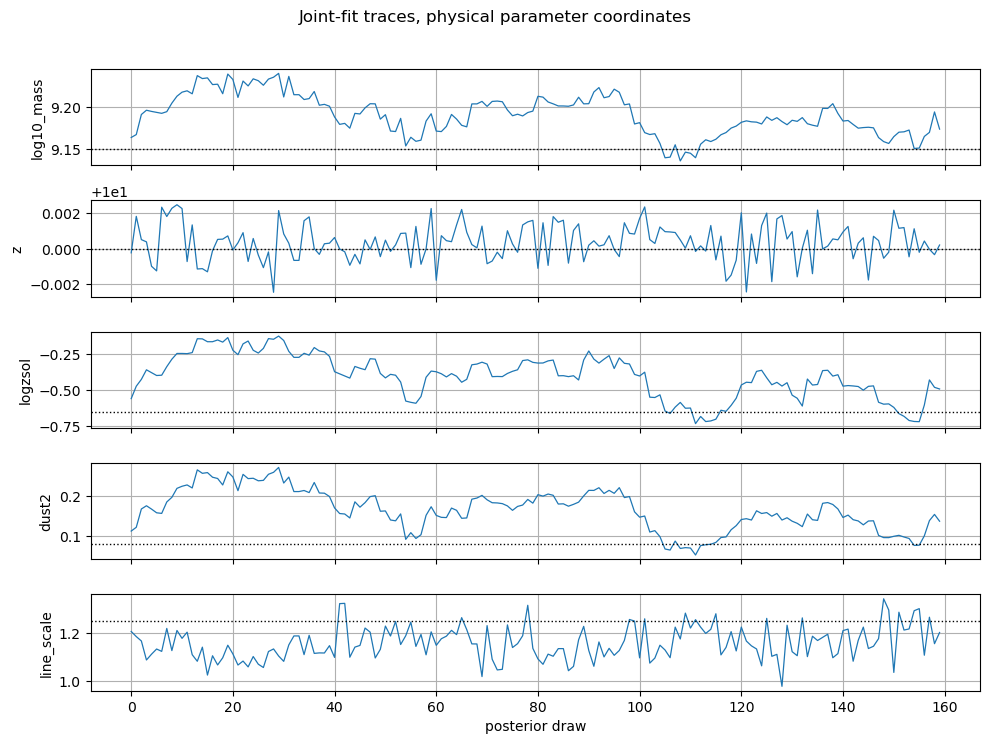

In [9]:
n_param = len(theta_names)
fig, axes = plt.subplots(n_param, 1, figsize=(10, 1.45 * n_param), sharex=True)
for i, ax in enumerate(np.atleast_1d(axes)):
    ax.plot(samples[:, i], lw=0.9)
    ax.axhline(truth[i], color="black", ls=":", lw=1)
    ax.set_ylabel(theta_names[i])
axes[-1].set_xlabel("posterior draw")
fig.suptitle("Joint-fit traces, physical parameter coordinates", y=1.02)
fig.tight_layout()

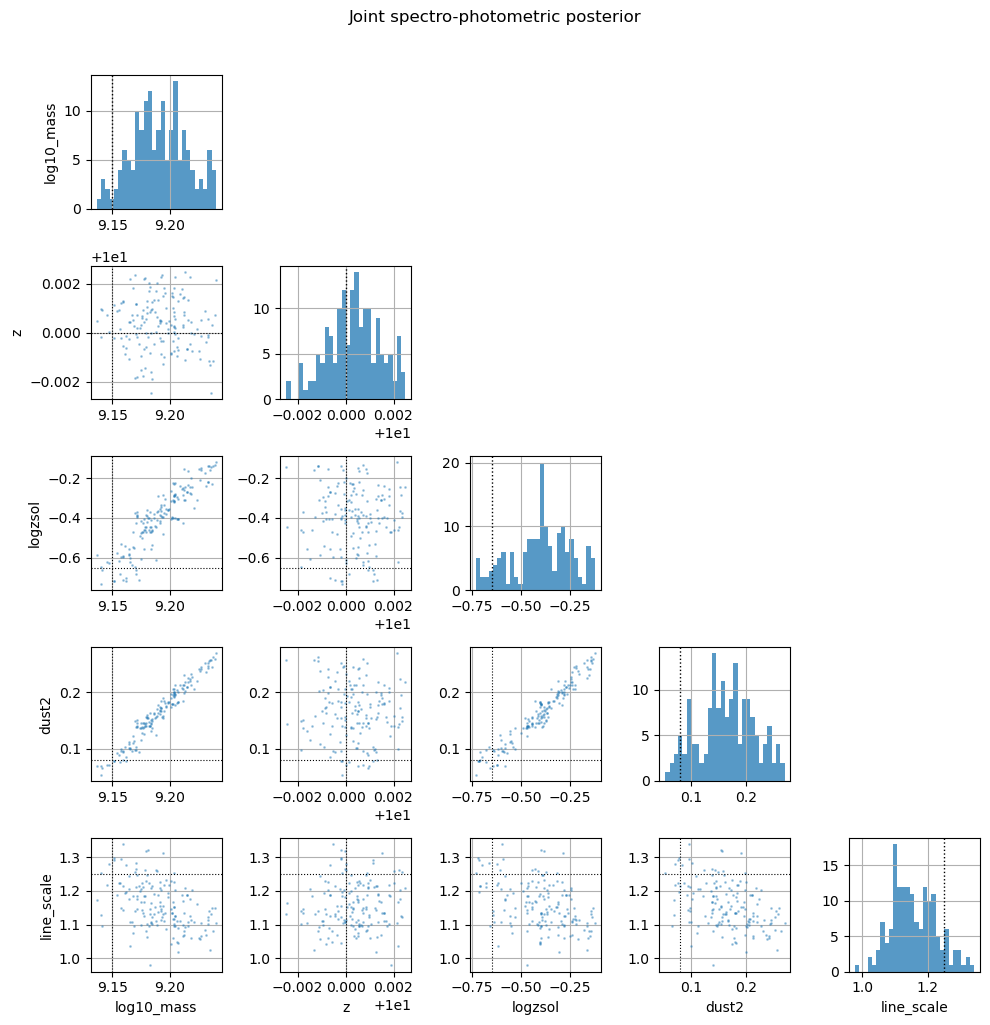

In [10]:
fig, axes = plt.subplots(n_param, n_param, figsize=(2.0 * n_param, 2.0 * n_param))
for i in range(n_param):
    for j in range(n_param):
        ax = axes[i, j]
        if i == j:
            ax.hist(samples[:, i], bins=28, color="tab:blue", alpha=0.75)
            ax.axvline(truth[i], color="black", ls=":", lw=1)
        elif i > j:
            ax.plot(samples[:, j], samples[:, i], ".", ms=2, alpha=0.35)
            ax.axvline(truth[j], color="black", ls=":", lw=0.8)
            ax.axhline(truth[i], color="black", ls=":", lw=0.8)
        else:
            ax.axis("off")
        if i == n_param - 1 and j <= i:
            ax.set_xlabel(theta_names[j])
        if j == 0 and i >= j:
            ax.set_ylabel(theta_names[i])
fig.suptitle("Joint spectro-photometric posterior", y=1.02)
fig.tight_layout()

## Posterior predictive checks

The same posterior samples are pushed through both data spaces. This is the main audit plot: if spectrum and photometry disagree, it means either the data construction, unit conversion, filter integration, or likelihood combination is wrong.

In [11]:
def pixel_model_for_theta(theta):
    state = model.run_modules_mass_scaled(jnp.asarray(theta))
    return np.asarray(
        model_spectrum_on_observed_pixels(
            state.wave_obs_a,
            state.flux_lambda_cgs,
            jnp.asarray(spectral_wave_a),
            jnp.asarray(spectral_edges_a),
            resample_mode="bin",
            resolving_power=resolving_power,
        )
    )


predict_photometry_jit = jax.jit(model.predict_photometry)


def photometry_for_theta(theta):
    return np.asarray(predict_photometry_jit(jnp.asarray(theta)))


posterior_subset = samples[np.linspace(0, samples.shape[0] - 1, min(80, samples.shape[0]), dtype=int)]
pred_spec = np.asarray([pixel_model_for_theta(theta) for theta in posterior_subset])
pred_phot = np.asarray([photometry_for_theta(theta) for theta in posterior_subset])

spec_q16, spec_q50, spec_q84 = np.percentile(pred_spec, [16, 50, 84], axis=0)
phot_q16, phot_q50, phot_q84 = np.percentile(pred_phot, [16, 50, 84], axis=0)
truth_pixel = pixel_model_for_theta(truth)
truth_phot = photometry_for_theta(truth)
residual_sigma = (observed_flux - spec_q50) / sigma_flux
phot_residual_sigma = (phot_observed_maggies - phot_q50) / phot_sigma_maggies

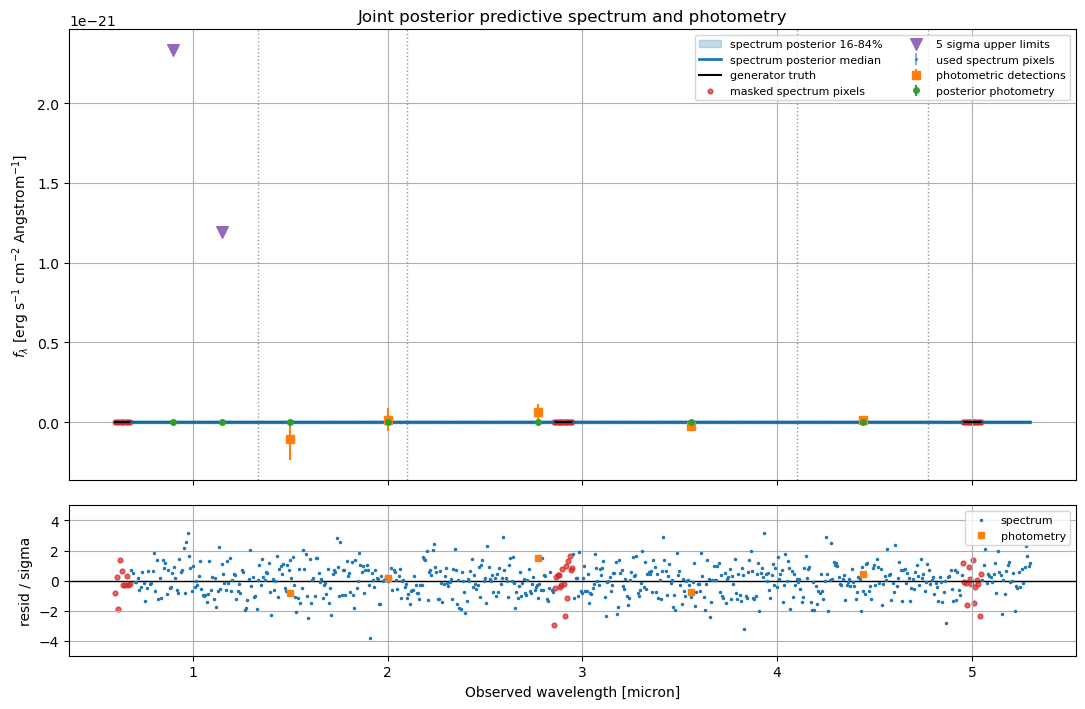

In [12]:
fig, (ax, rx) = plt.subplots(2, 1, figsize=(11, 7.2), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
wave_um = spectral_wave_a / 1e4
ax.fill_between(wave_um, spec_q16, spec_q84, color="tab:blue", alpha=0.25, label="spectrum posterior 16-84%")
ax.plot(wave_um, spec_q50, color="tab:blue", lw=2, label="spectrum posterior median")
ax.plot(wave_um, truth_pixel, color="black", lw=1.5, label="generator truth")
ax.errorbar(wave_um[spectral_mask], observed_flux[spectral_mask], yerr=sigma_flux[spectral_mask], fmt=".", ms=3, alpha=0.55, label="used spectrum pixels")
ax.scatter(wave_um[~spectral_mask], observed_flux[~spectral_mask], s=12, color="tab:red", alpha=0.7, label="masked spectrum pixels")

phot_flam_q50 = maggies_to_flam_at_wave(phot_q50, filter_effective_wave_a)
phot_flam_q16 = maggies_to_flam_at_wave(phot_q16, filter_effective_wave_a)
phot_flam_q84 = maggies_to_flam_at_wave(phot_q84, filter_effective_wave_a)
phot_yerr = np.vstack([phot_flam_q50 - phot_flam_q16, phot_flam_q84 - phot_flam_q50])
ax.errorbar(filter_effective_wave_a[is_det] / 1.0e4, phot_flam[is_det], yerr=phot_sigma_flam[is_det], fmt="s", ms=6, color="tab:orange", label="photometric detections")
ax.errorbar(filter_effective_wave_a / 1.0e4, phot_flam_q50, yerr=phot_yerr, fmt="o", ms=4, color="tab:green", label="posterior photometry")
ax.scatter(filter_effective_wave_a[upper_limit_mask] / 1.0e4, upper_flam[upper_limit_mask], marker="v", s=70, color="tab:purple", label="5 sigma upper limits")

for x in [lya_obs_um, 1908.7 * 11.0 / 1e4, 3727.0 * 11.0 / 1e4, 4341.0 * 11.0 / 1e4]:
    ax.axvline(x, color="0.6", ls=":", lw=1)
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
ax.set_title("Joint posterior predictive spectrum and photometry")
ax.legend(loc="upper right", ncol=2, fontsize=8)

rx.axhline(0.0, color="black", lw=1)
rx.plot(wave_um[spectral_mask], residual_sigma[spectral_mask], ".", ms=3, label="spectrum")
rx.scatter(wave_um[~spectral_mask], residual_sigma[~spectral_mask], s=12, color="tab:red", alpha=0.7)
rx.errorbar(filter_effective_wave_a[is_det] / 1.0e4, phot_residual_sigma[is_det], fmt="s", ms=5, color="tab:orange", label="photometry")
rx.set_xlabel("Observed wavelength [micron]")
rx.set_ylabel("resid / sigma")
rx.set_ylim(-5, 5)
rx.legend(loc="upper right", fontsize=8)
fig.tight_layout()

In [13]:
active_residual = residual_sigma[spectral_mask]
metrics = {
    "n_spectral_pixels": int(spectral_mask.size),
    "n_active_spectral_pixels": int(spectral_mask.sum()),
    "n_photometric_bands": int(len(filters.names)),
    "n_upper_limits": int(upper_limit_mask.sum()),
    "spectrum_median_abs_residual_sigma": float(np.median(np.abs(active_residual))),
    "spectrum_rms_residual_sigma": float(np.sqrt(np.mean(active_residual**2))),
    "phot_detection_rms_residual_sigma": float(np.sqrt(np.mean(phot_residual_sigma[is_det] ** 2))),
    "runtime_seconds": float(runtime),
}
metrics

{'n_spectral_pixels': 712,
 'n_active_spectral_pixels': 672,
 'n_photometric_bands': 7,
 'n_upper_limits': 2,
 'spectrum_median_abs_residual_sigma': 0.6970128651886633,
 'spectrum_rms_residual_sigma': 1.0340802369682385,
 'phot_detection_rms_residual_sigma': 0.8574912937701885,
 'runtime_seconds': 37.97391716693528}

## Audit notes

1. **Data entering the fit**: one simulated NIRSpec-like `f_lambda` spectrum plus seven broad-band fluxes in maggies.
2. **Transformations**: the model builds a rest-frame luminosity spectrum, applies toy nebular emission, attenuation, IGM absorption, redshift, luminosity distance, and mass scaling.
3. **Units**: spectra use observed Angstrom and cgs `f_lambda`; photometry uses maggies. Plotting converts maggies to an effective-wavelength `f_lambda` only for visualization.
4. **Masks/cuts**: masked spectral pixels have zero likelihood weight. `F090W` and `F115W` are active upper-limit bands using Gaussian CDF likelihood terms.
5. **Normalization**: `log10_mass` is applied exactly once inside `run_modules_mass_scaled` before spectral comparison and filter integration.
6. **Final quantity**: `model.log_prob(theta, joint_data)` returns log prior plus spectrum likelihood plus photometry likelihood.
7. **Most important code to audit**: `GaussianSpectroPhotometricData`, `GaussianPhotometricData` upper-limit construction, `model_spectrum_on_observed_pixels`, and the mass-scaling call in `JaxSedModel`.
8. **Sanity checks**: posterior median should recover the generator within the toy noise level; masked spectral windows should not drive the residuals; upper limits should constrain blue flux without pretending to be detections.